In [ ]:
# Library 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
pd.set_option('display.max_rows', None)

# **DATA UNDERSTANDING**

### **IMPORT DATA** 

In [ ]:
# Import Data dengan format CSV
df = pd.read_csv("../data/raw/loan_data_2007_2014.csv")

# Melihat Beberapa Data Urutan Atas
df.head()


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\2044369641.py:1: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/loan_data_2007_2014.csv")


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **CEK STRUKTUR DATA**

In [63]:
# Mengetahui Jumlah Baris dan Kolom
df.shape

(466285, 75)

In [64]:
# Mengetahui Nama Kolom, Jumlah baris Non-Null dan Tipe Data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

### **STATISTIK DASAR**

In [ ]:
# Melihat Statistik Deskriptif data Numerikal

df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [ ]:
# Melihat Statistik untuk Data Kategorikal
df.describe(include="object")

C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,...,purpose,title,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,next_pymnt_d,last_credit_pull_d,application_type
count,466285,466285,466285,438697,445277,466285,466285,466285,466285,466285,...,466285,466264,466285,466285,466256,466285,465909,239071,466243,466285
unique,2,7,35,205475,11,6,3,91,9,2,...,14,63098,888,50,664,2,98,100,103,1
top,36 months,B,B3,Teacher,10+ years,MORTGAGE,Verified,Oct-14,Current,n,...,debt_consolidation,Debt consolidation,945xx,CA,Oct-00,f,Jan-16,Feb-16,Jan-16,INDIVIDUAL
freq,337953,136929,31686,5399,150049,235875,168055,38782,224226,466276,...,274195,164075,5304,71450,3674,303005,179620,208393,327699,466285


### **CEK MISSING & DUPLICATE VALUE**

In [ ]:
# Cek Missing Value
df.isnull().sum().sort_values(ascending=False)


max_bal_bc                     466285
open_rv_24m                    466285
inq_fi                         466285
open_rv_12m                    466285
il_util                        466285
mths_since_rcnt_il             466285
total_bal_il                   466285
open_il_24m                    466285
open_il_12m                    466285
open_il_6m                     466285
open_acc_6m                    466285
dti_joint                      466285
annual_inc_joint               466285
verification_status_joint      466285
all_util                       466285
inq_last_12m                   466285
total_cu_tl                    466285
mths_since_last_record         403647
mths_since_last_major_derog    367311
desc                           340304
mths_since_last_delinq         250351
next_pymnt_d                   227214
tot_coll_amt                    70276
total_rev_hi_lim                70276
tot_cur_bal                     70276
emp_title                       27588
emp_length  

In [ ]:
# Cek Duplicated Value
df.duplicated().sum()


np.int64(0)

### **TARGET VARIABLE UNDERSTANDING**

In [ ]:
# Mengecek Isi Variabel Target & Melihatnya dalam Proporsi
loan_status_summary = (
    df["loan_status"]
    .value_counts()
    .to_frame()
)

loan_status_summary["Percentage (%)"] = (
    df["loan_status"]
    .value_counts(normalize=True) * 100
).round(2)

loan_status_summary


,count,Percentage (%)
loan_status,,
Current,224226,48.09
Fully Paid,184739,39.62
Charged Off,42475,9.11
Late (31-120 days),6900,1.48
In Grace Period,3146,0.67
Does not meet the credit policy. Status:Fully Paid,1988,0.43
Late (16-30 days),1218,0.26
Default,832,0.18
Does not meet the credit policy. Status:Charged Off,761,0.16


------------

-----------

--------------------

# **EXPLORATORY DATA ANALYSIS (EDA)**

### **TARGET VARIABLE ANALYSIS**

In [ ]:
# Kategori yang Digunakan dalam Variabel Target untuk Analisis
final_status = [
    'Fully Paid',
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status: Fully Paid',
    'Does not meet the credit policy. Status: Charged Off'
]

df_final = df[df['loan_status'].isin(final_status)].copy()

In [74]:
# Menentukan Good & Bad dalam credit risk
df_final['target'] = df_final['loan_status'].map({
    'Fully Paid': 0,
    'Does not meet the credit policy. Status: Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status: Charged Off': 1
})

In [ ]:
# Melihat Proporsi Variabel Target untuk Kategori Good & Bad
df_final['target'].value_counts()
df_final['target'].value_counts(normalize=True) * 100

target
0    81.009533
1    18.990467
Name: proportion, dtype: float64

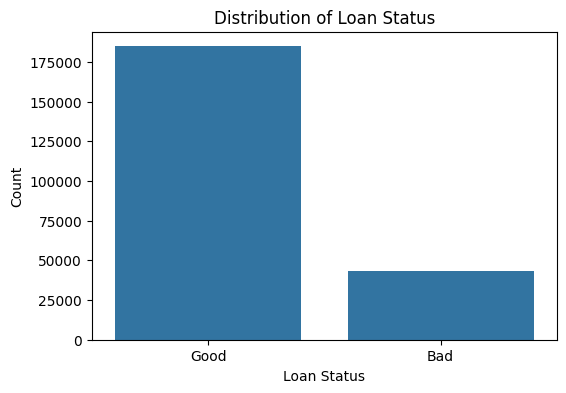

In [ ]:
# Melihat Distribusi dari Variabel Target
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df_final)

plt.xticks(ticks=[0,1], labels=['Good', 'Bad'])
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

### **MISSING VALUE DETECTION**

In [ ]:
# Melihat Variabel yang Memiliki Missing Value Diatas 0%
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]

max_bal_bc                     100.000000
open_rv_24m                    100.000000
inq_fi                         100.000000
open_rv_12m                    100.000000
il_util                        100.000000
mths_since_rcnt_il             100.000000
total_bal_il                   100.000000
open_il_24m                    100.000000
open_il_12m                    100.000000
open_il_6m                     100.000000
open_acc_6m                    100.000000
dti_joint                      100.000000
annual_inc_joint               100.000000
verification_status_joint      100.000000
all_util                       100.000000
inq_last_12m                   100.000000
total_cu_tl                    100.000000
mths_since_last_record          86.566585
mths_since_last_major_derog     78.773926
desc                            72.981975
mths_since_last_delinq          53.690554
next_pymnt_d                    48.728567
tot_coll_amt                    15.071469
total_rev_hi_lim                15

### **UNIVARIATE ANALYSIS**

##### **NUMERICAL FEATURES**

In [ ]:
# Fungsi untuk Analisis Univariate Variabel Numerikal
def univariate_numerical(df, column, bins=30):
    
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    
    # Histogram
    sns.histplot(df[column], bins=bins, kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(y=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot of {column}')
    axes[1].set_xlabel(column)
    
    plt.tight_layout()
    plt.show()
    
    # Statistik deskriptif
    print(f"\nDescriptive Statistics for {column}")
    print(df[column].describe())


In [ ]:
# Variabel Numerikal yang Digunakan dalam Analisis
numerical_cols = [
    'loan_amnt',
    'funded_amnt',
    'int_rate',
    'annual_inc',
    'dti',
    'revol_util',
    'installment',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'total_acc'
]

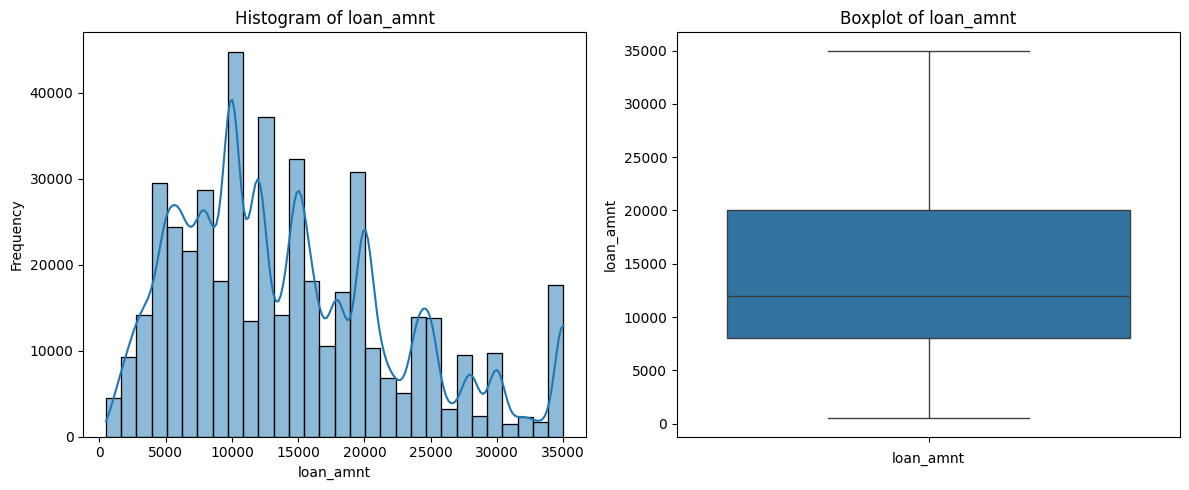


Descriptive Statistics for loan_amnt
count    466285.000000
mean      14317.277577
std        8286.509164
min         500.000000
25%        8000.000000
50%       12000.000000
75%       20000.000000
max       35000.000000
Name: loan_amnt, dtype: float64


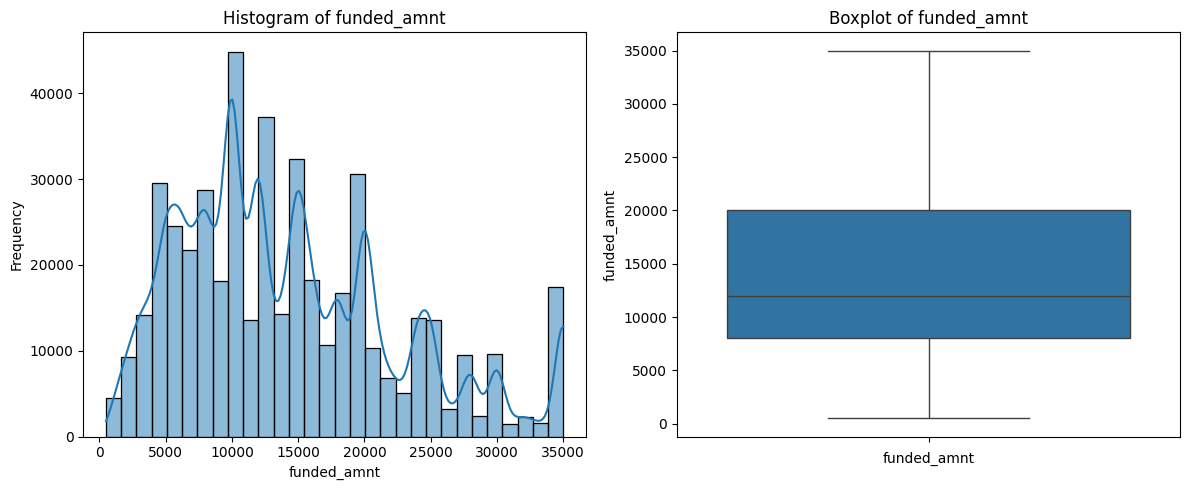


Descriptive Statistics for funded_amnt
count    466285.000000
mean      14291.801044
std        8274.371300
min         500.000000
25%        8000.000000
50%       12000.000000
75%       20000.000000
max       35000.000000
Name: funded_amnt, dtype: float64


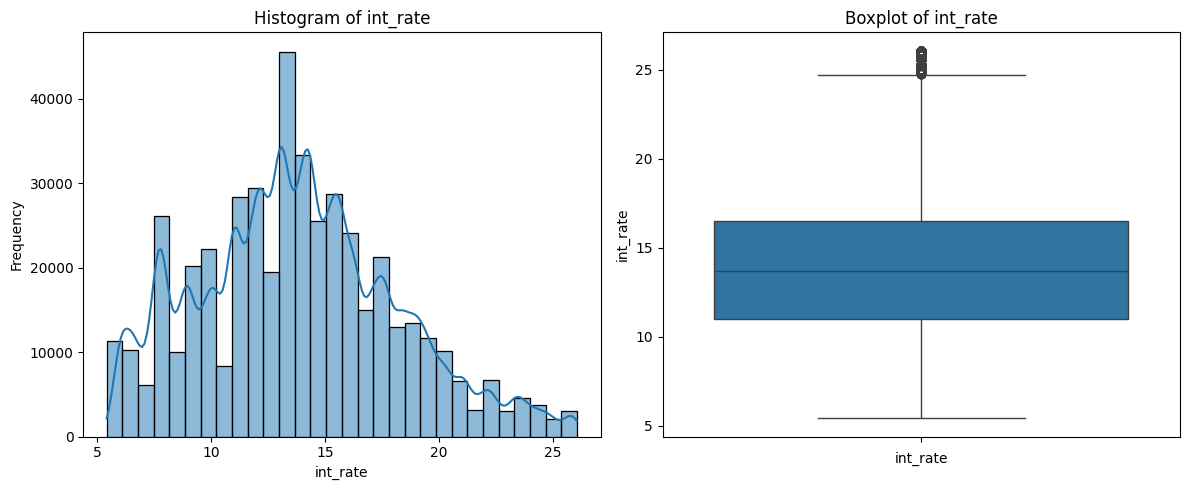


Descriptive Statistics for int_rate
count    466285.000000
mean         13.829236
std           4.357587
min           5.420000
25%          10.990000
50%          13.660000
75%          16.490000
max          26.060000
Name: int_rate, dtype: float64


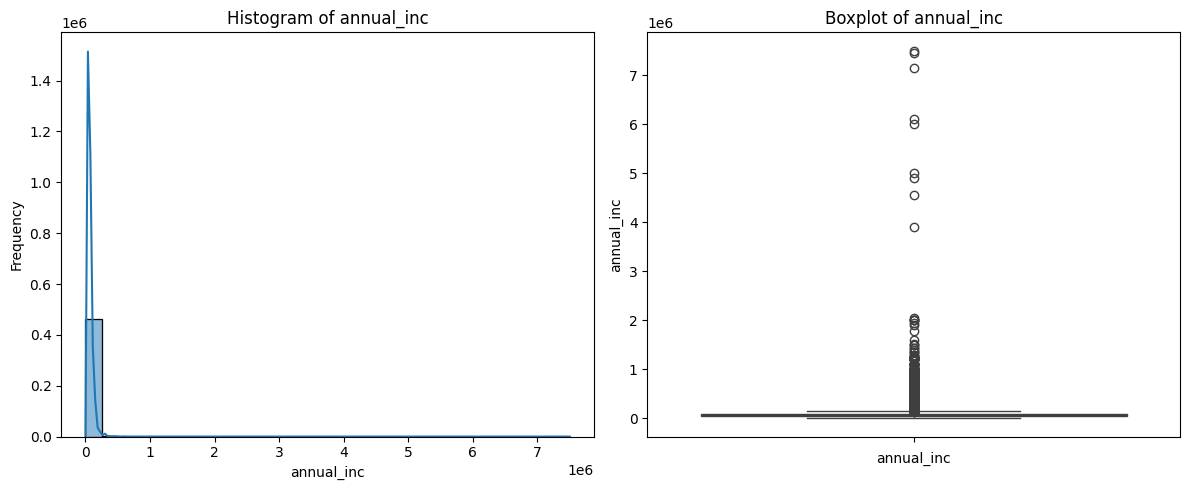


Descriptive Statistics for annual_inc
count    4.662810e+05
mean     7.327738e+04
std      5.496357e+04
min      1.896000e+03
25%      4.500000e+04
50%      6.300000e+04
75%      8.896000e+04
max      7.500000e+06
Name: annual_inc, dtype: float64


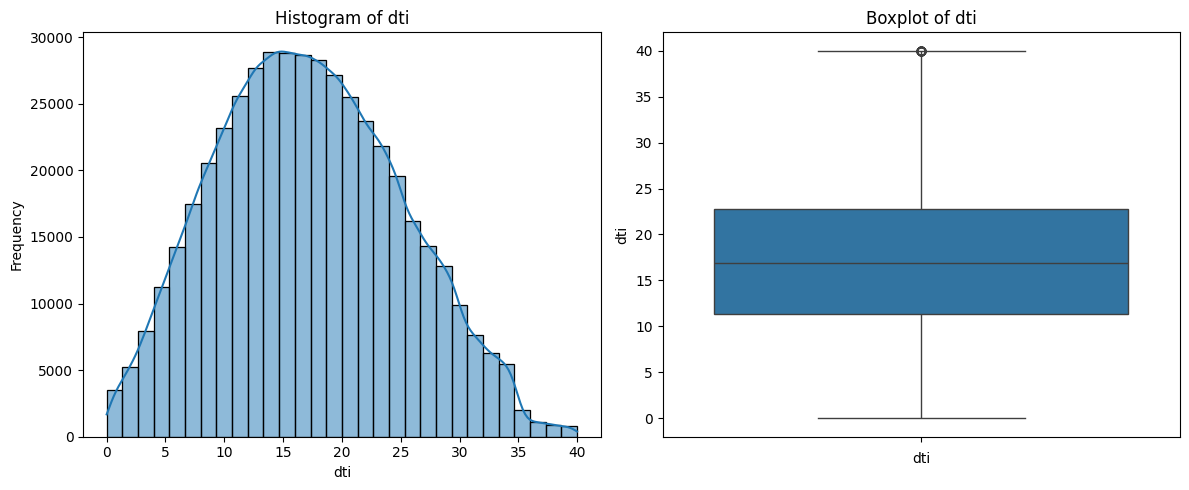


Descriptive Statistics for dti
count    466285.000000
mean         17.218758
std           7.851121
min           0.000000
25%          11.360000
50%          16.870000
75%          22.780000
max          39.990000
Name: dti, dtype: float64


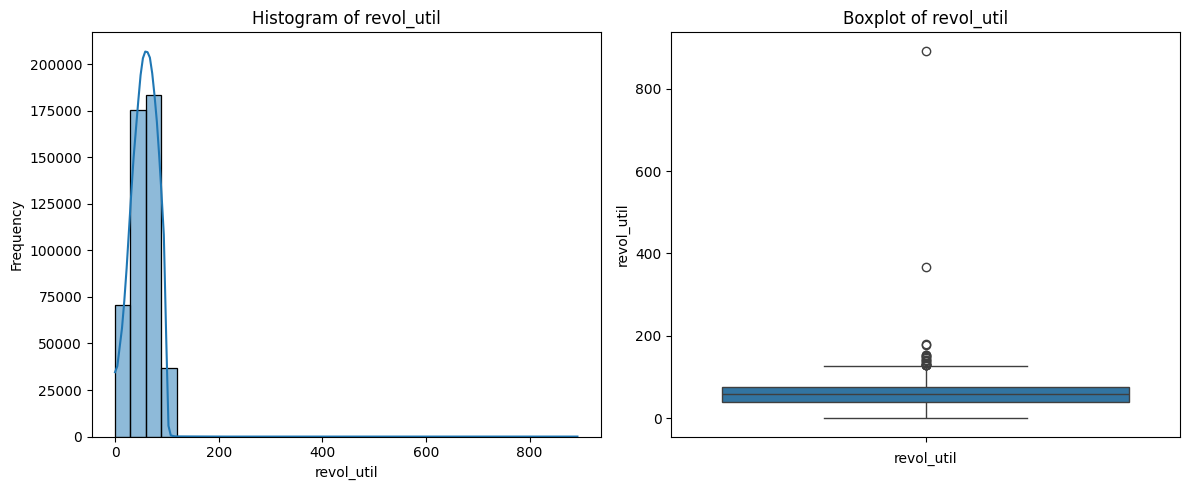


Descriptive Statistics for revol_util
count    465945.000000
mean         56.176947
std          23.732628
min           0.000000
25%          39.200000
50%          57.600000
75%          74.700000
max         892.300000
Name: revol_util, dtype: float64


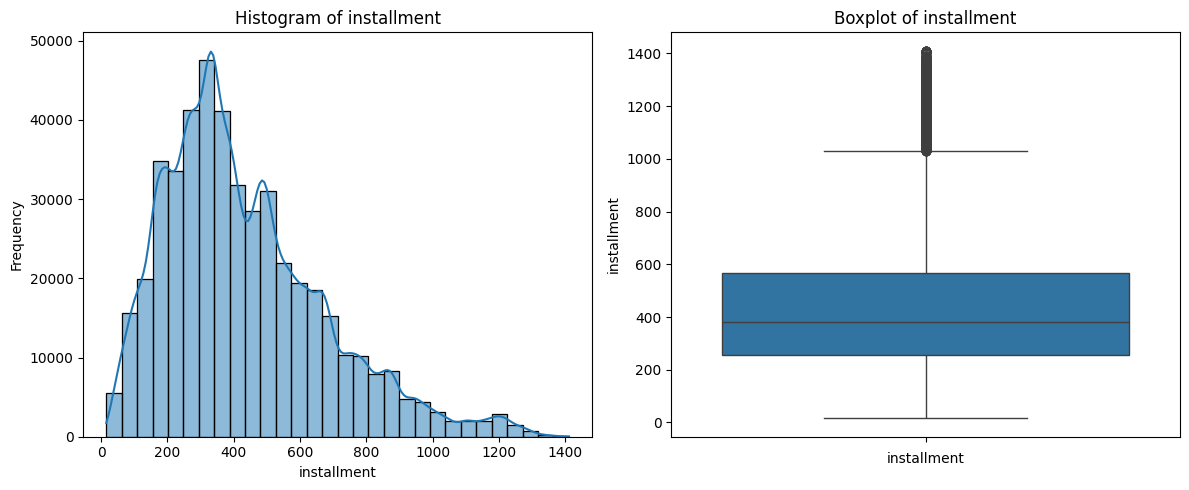


Descriptive Statistics for installment
count    466285.000000
mean        432.061201
std         243.485550
min          15.670000
25%         256.690000
50%         379.890000
75%         566.580000
max        1409.990000
Name: installment, dtype: float64


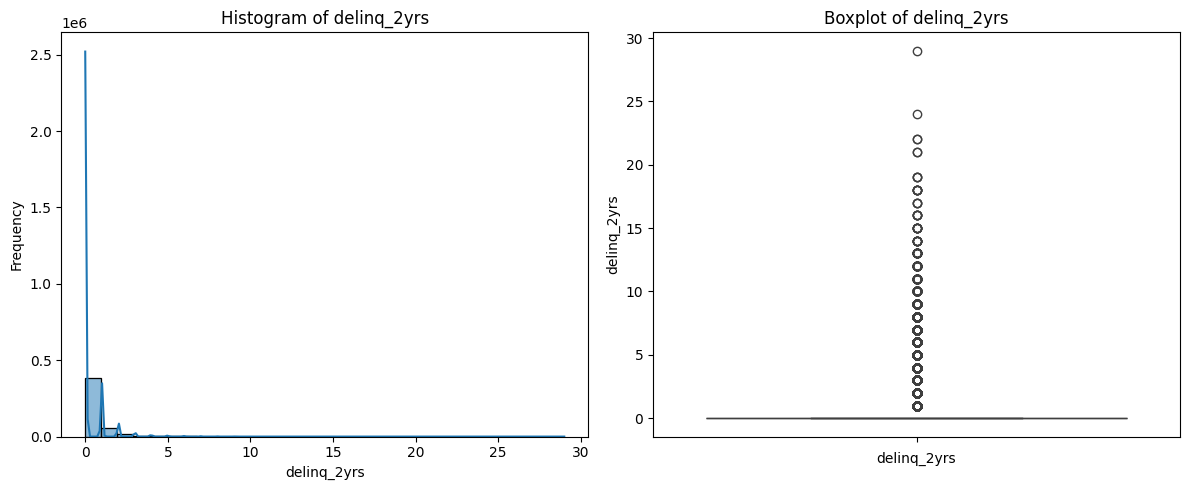


Descriptive Statistics for delinq_2yrs
count    466256.000000
mean          0.284678
std           0.797365
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          29.000000
Name: delinq_2yrs, dtype: float64


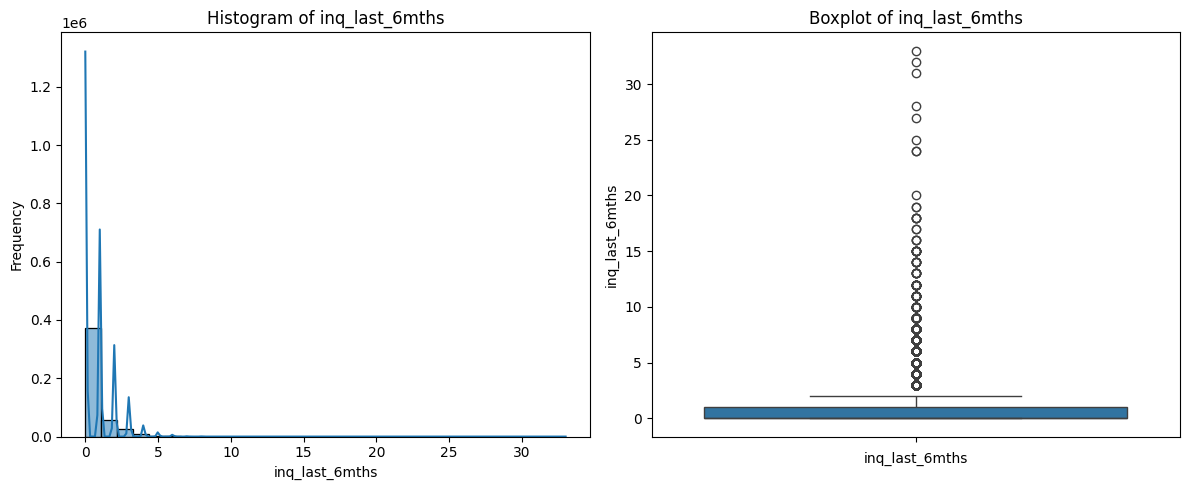


Descriptive Statistics for inq_last_6mths
count    466256.000000
mean          0.804745
std           1.091598
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          33.000000
Name: inq_last_6mths, dtype: float64


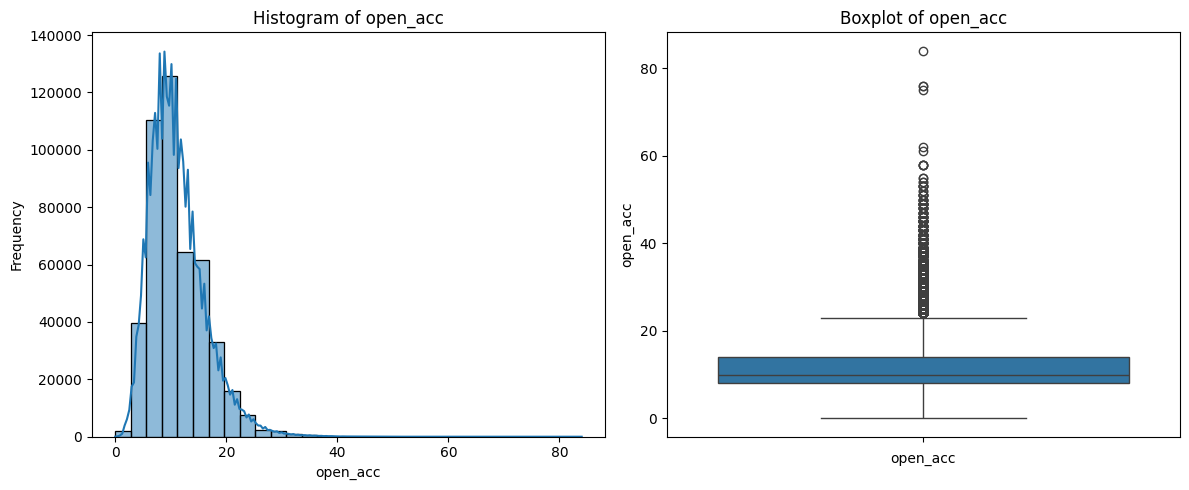


Descriptive Statistics for open_acc
count    466256.000000
mean         11.187069
std           4.987526
min           0.000000
25%           8.000000
50%          10.000000
75%          14.000000
max          84.000000
Name: open_acc, dtype: float64


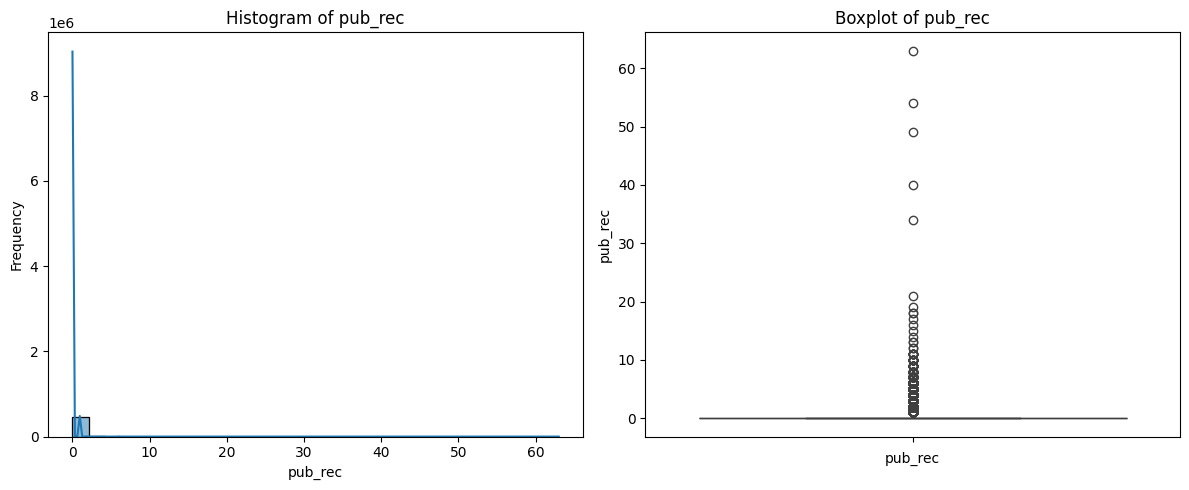


Descriptive Statistics for pub_rec
count    466256.000000
mean          0.160564
std           0.510863
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          63.000000
Name: pub_rec, dtype: float64


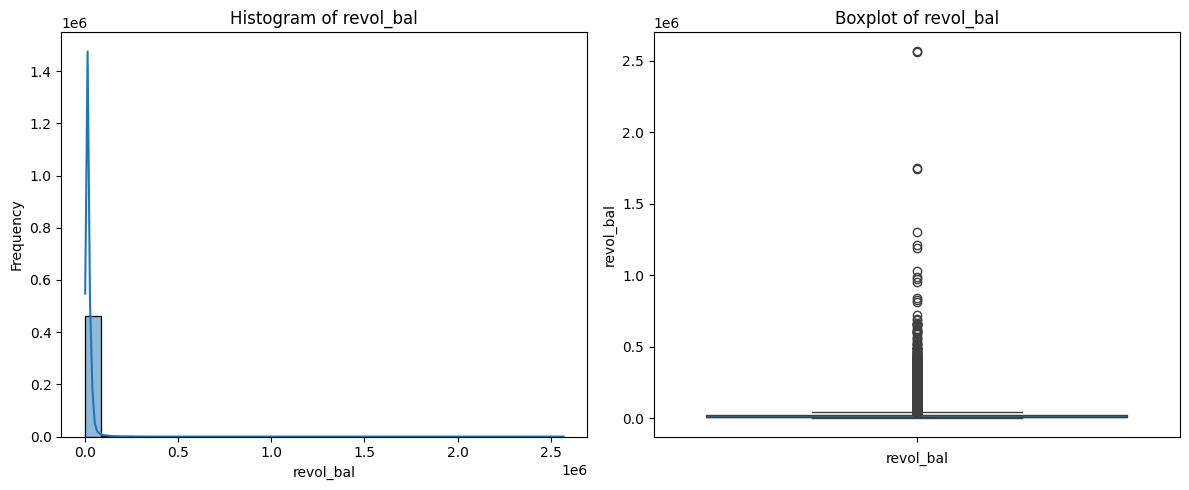


Descriptive Statistics for revol_bal
count    4.662850e+05
mean     1.623020e+04
std      2.067625e+04
min      0.000000e+00
25%      6.413000e+03
50%      1.176400e+04
75%      2.033300e+04
max      2.568995e+06
Name: revol_bal, dtype: float64


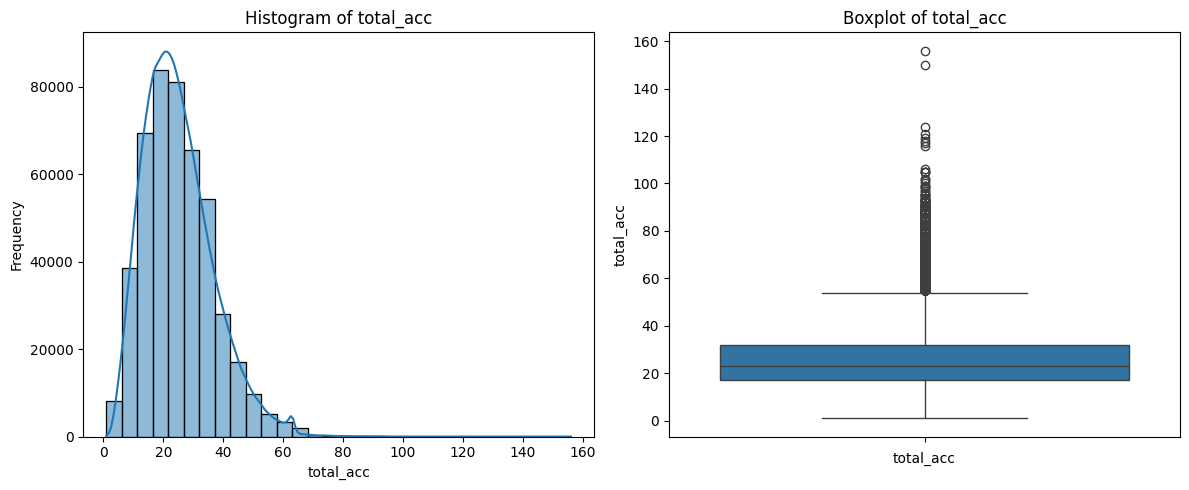


Descriptive Statistics for total_acc
count    466256.000000
mean         25.064430
std          11.600141
min           1.000000
25%          17.000000
50%          23.000000
75%          32.000000
max         156.000000
Name: total_acc, dtype: float64


In [ ]:
# Loop untuk Iterasi Semua Variabel Numerikal 
for col in numerical_cols:
    univariate_numerical(df, col)

##### **CATEGORICAL FEATURES**

In [ ]:
# Variabel Kategorikal yang Digunakan untuk Analisis
categorical_cols = [
    'home_ownership',
    'verification_status',
    'purpose',
    'grade',
    'sub_grade',
    'term',
    'emp_length'
]


In [ ]:
# Fungsi untuk Analisis Univariate Variabel Kategorikal
def univariate_categorical(df, column):

    
    data = df[column].value_counts()
     
    plt.figure(figsize=(12,6))
    sns.barplot(x=data.index, y=data.values)
    
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

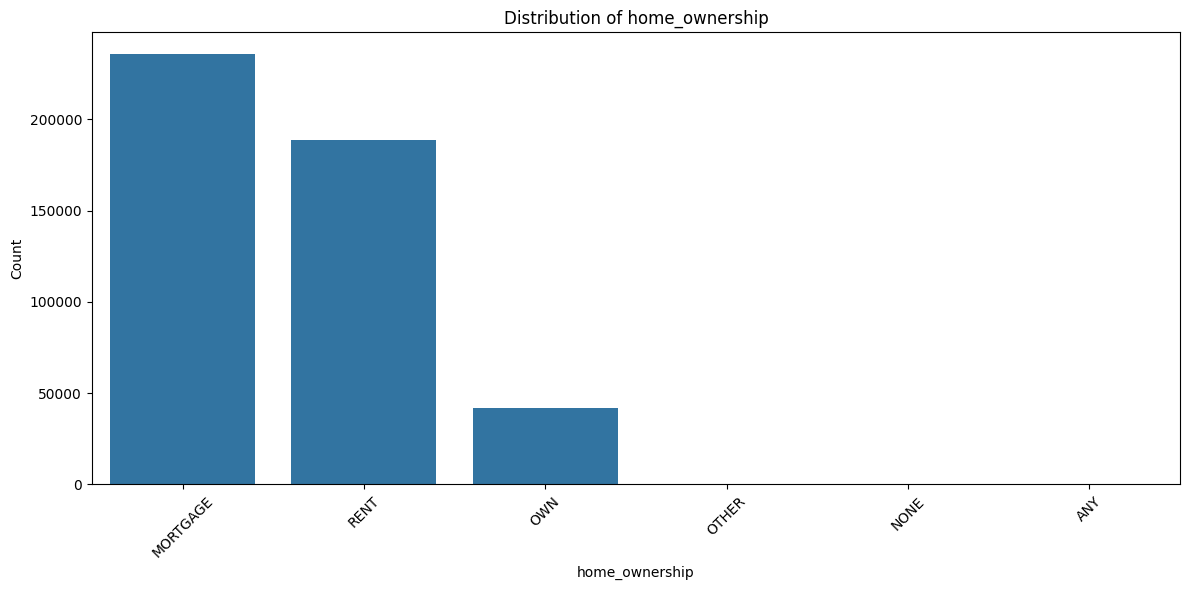

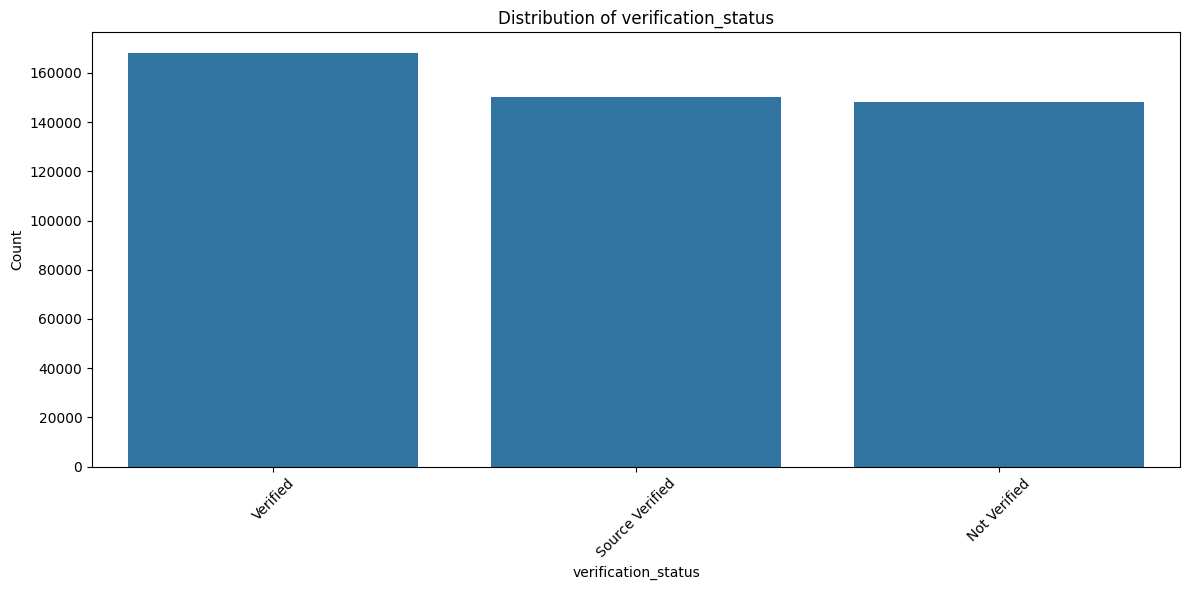

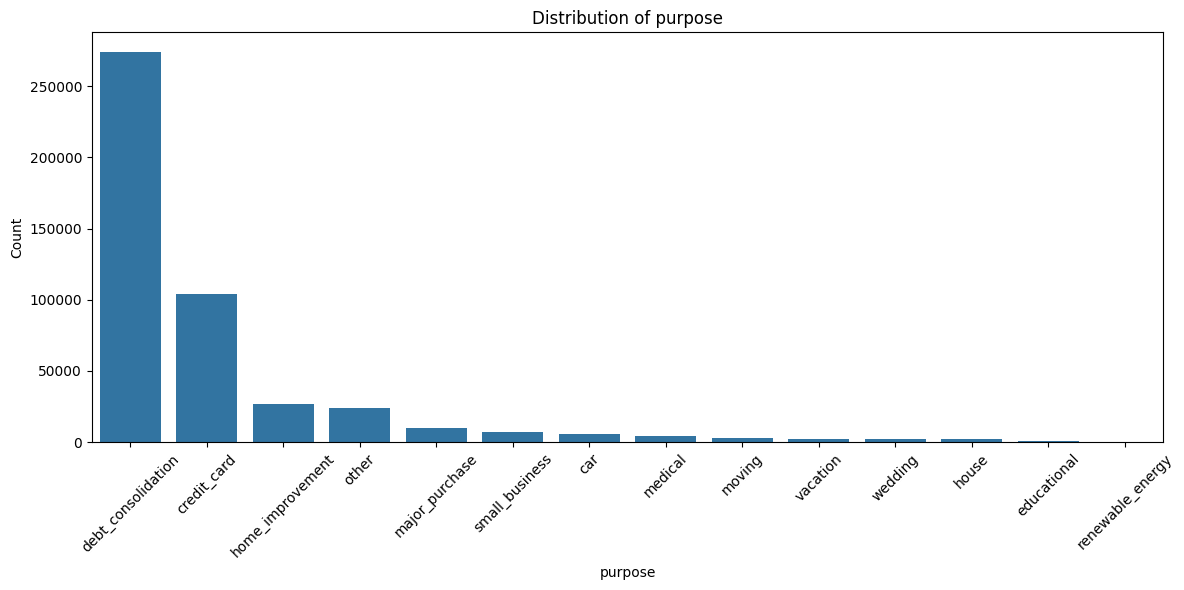

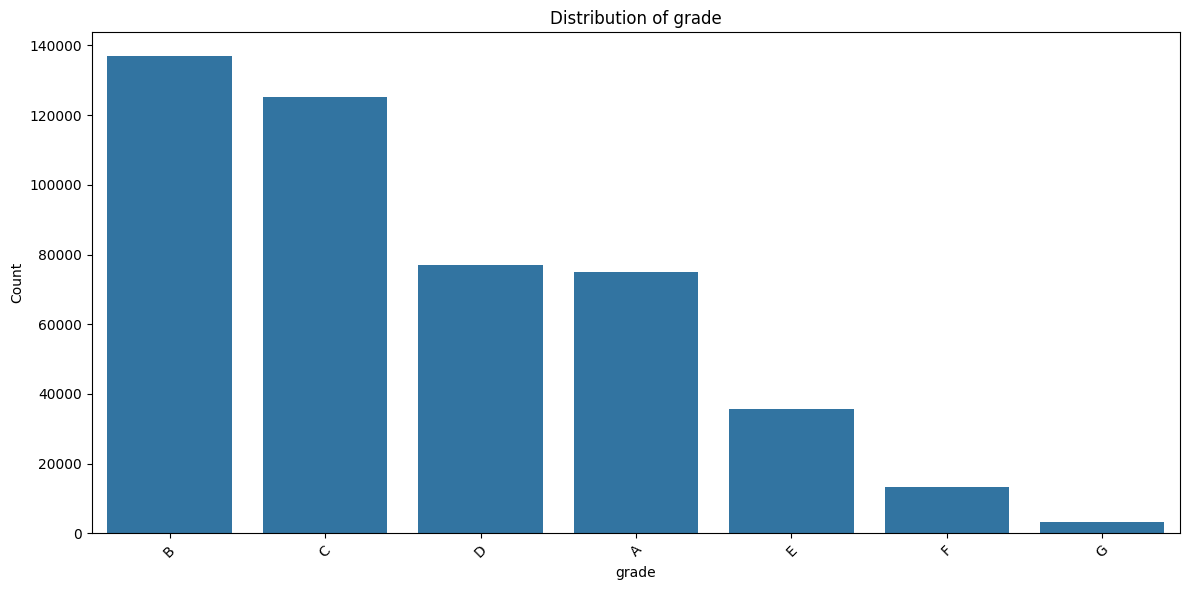

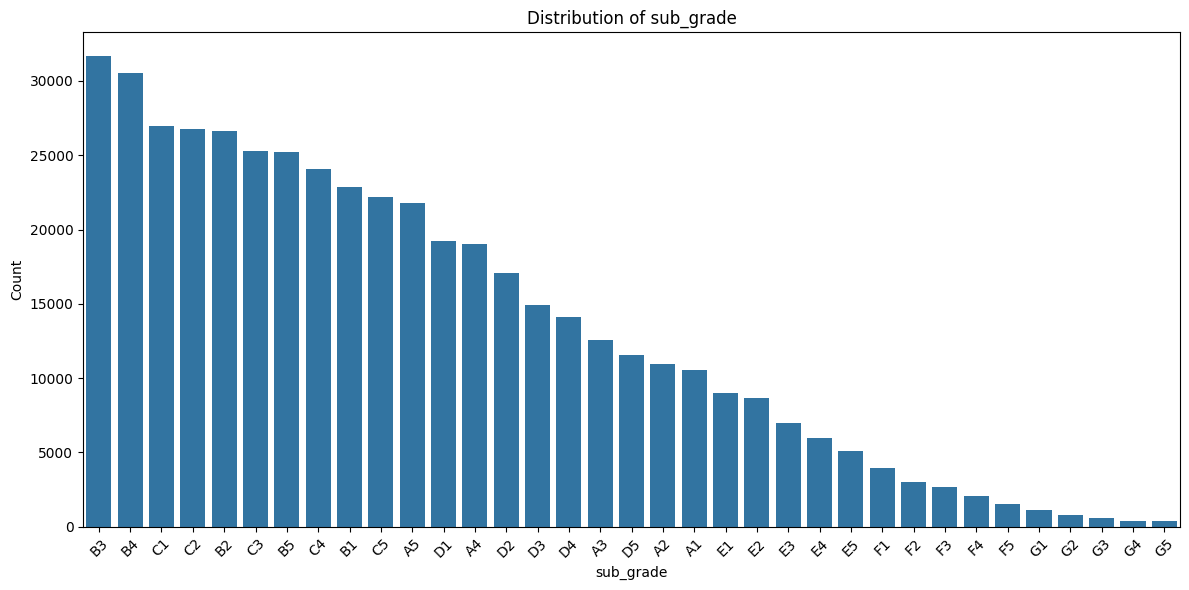

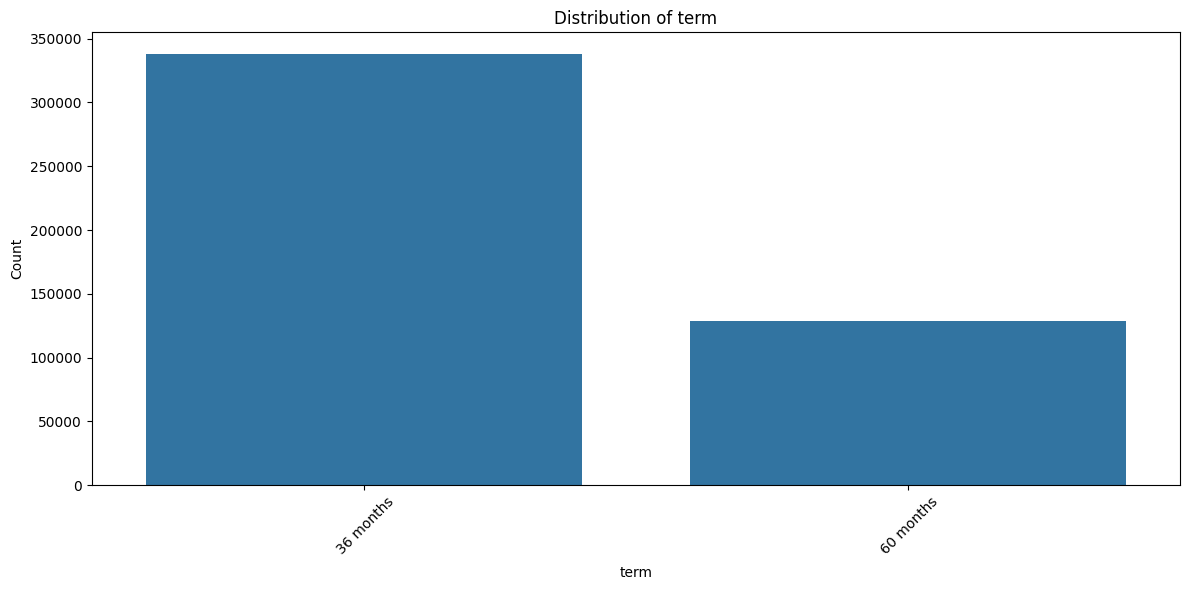

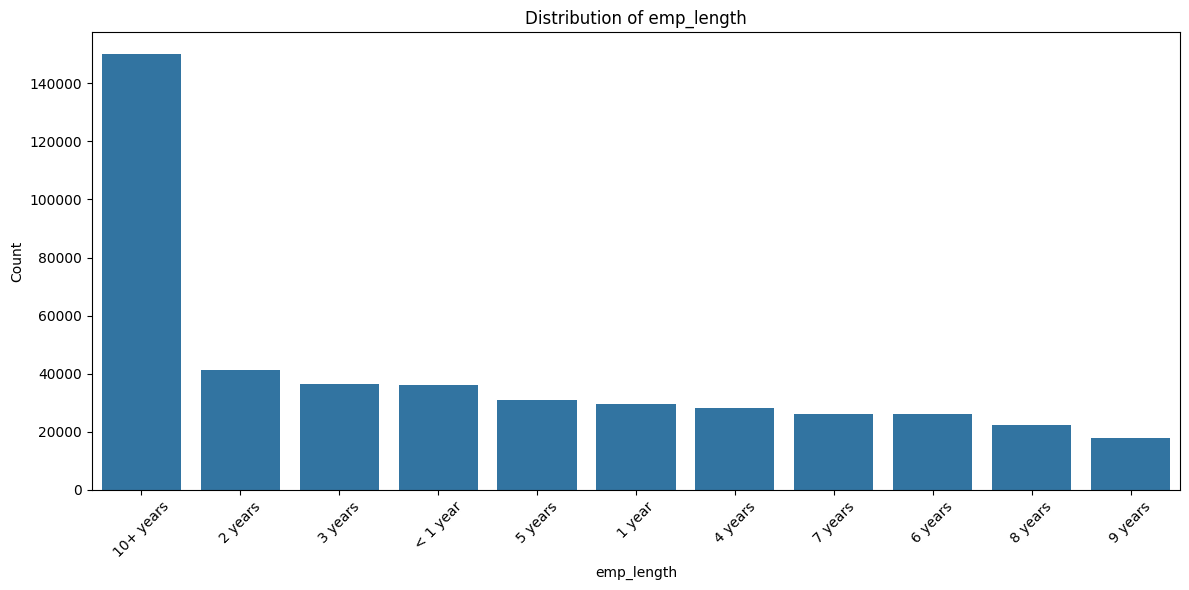

In [ ]:
# Loop untuk Iterasi Semua Variabel Kategorikal
for col in categorical_cols:
    univariate_categorical(df, col)


### **BIVARIATE ANALYSIS**

##### **NUMERICAL VS TARGET**

In [ ]:
# Fungsi untuk Analisis Bivariate Variabel Numerikal vs Target
def bivariate_numeric_target(df, feature, target):
    
    plt.figure(figsize=(8,5))
    ax = sns.boxplot(x=target, y=feature, data=df)
    
    ax.set_xticklabels(['Good', 'Bad'])  
    
    plt.title(f'{feature} vs Loan Status')
    plt.xlabel('Loan Status')
    plt.ylabel(feature)
    plt.show()
    
    print("\nMean per Class:")
    print(df.groupby(target)[feature].mean())


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


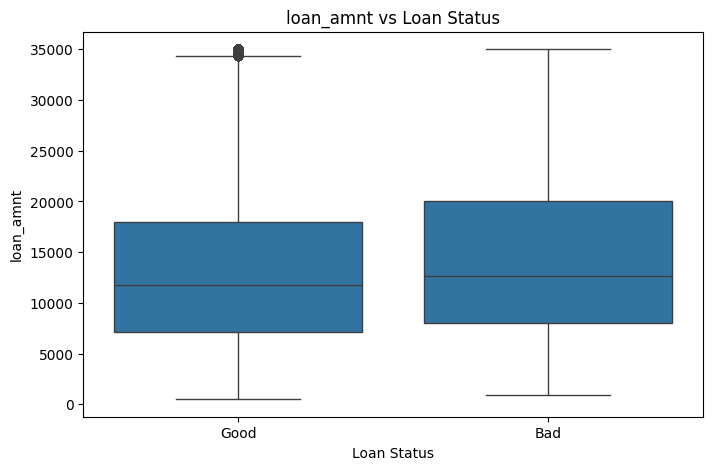


Mean per Class:
target
0    13214.394226
1    14533.477267
Name: loan_amnt, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


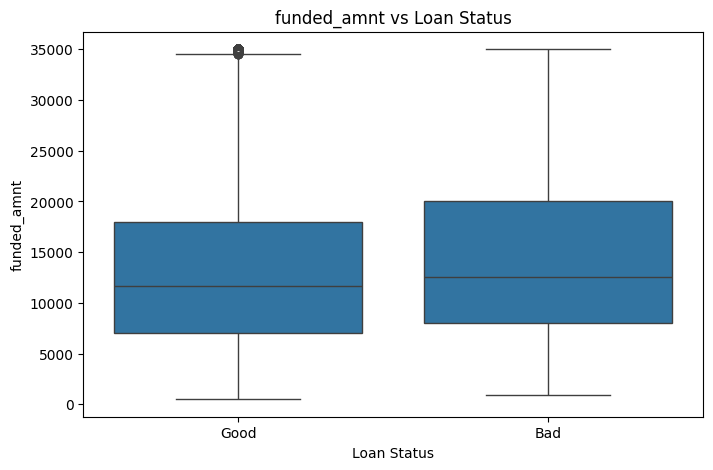


Mean per Class:
target
0    13169.988064
1    14485.892004
Name: funded_amnt, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


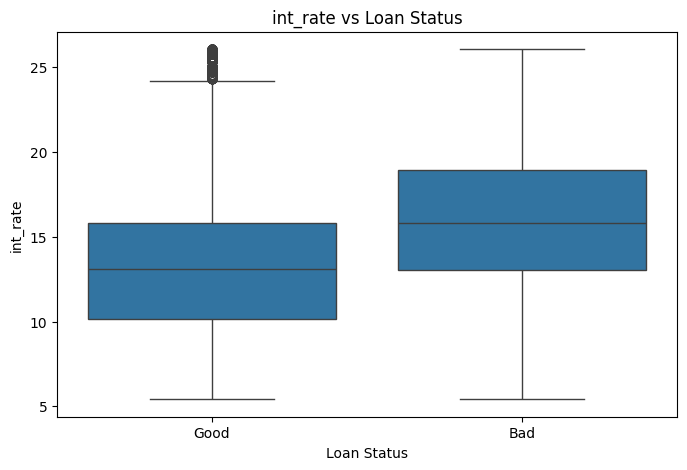


Mean per Class:
target
0    13.255943
1    16.001477
Name: int_rate, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


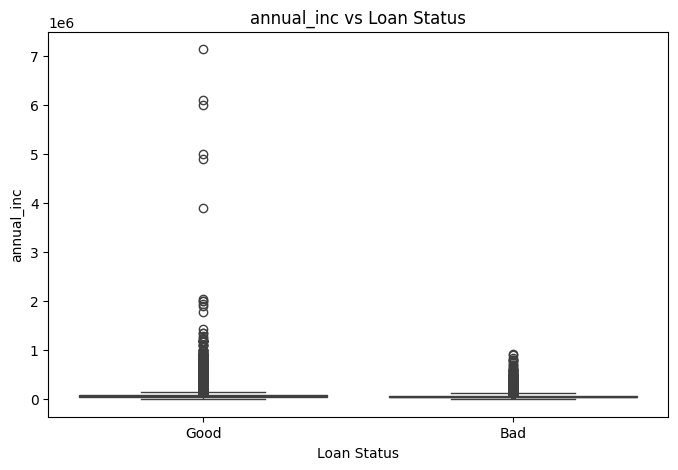


Mean per Class:
target
0    73709.612302
1    64766.921296
Name: annual_inc, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


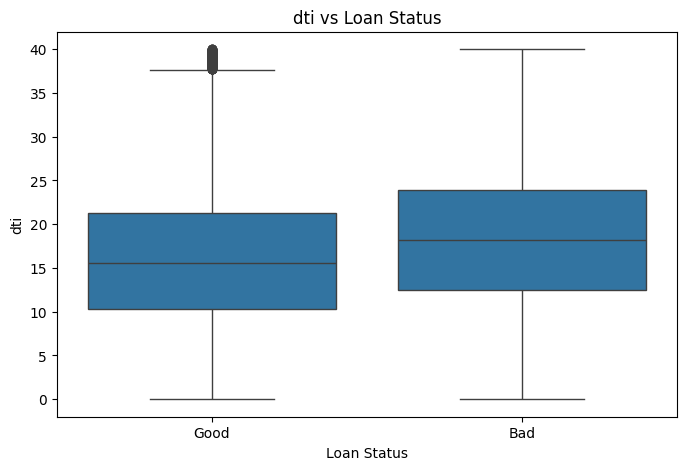


Mean per Class:
target
0    15.937997
1    18.239818
Name: dti, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


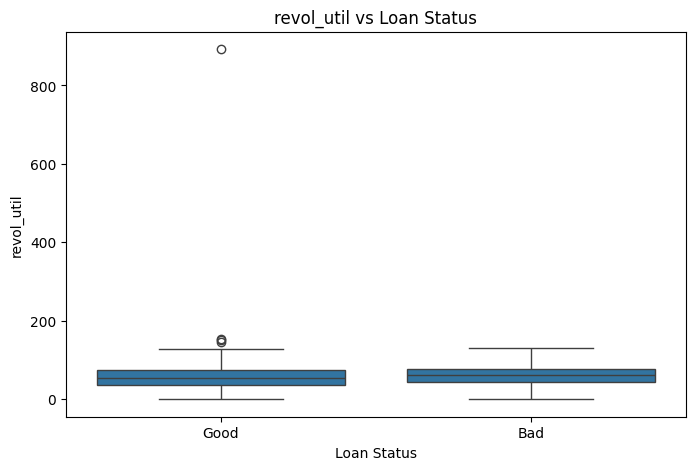


Mean per Class:
target
0    53.728864
1    59.646884
Name: revol_util, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


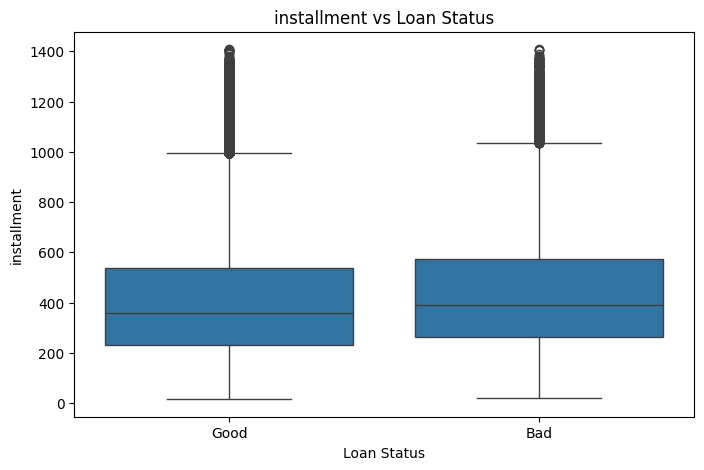


Mean per Class:
target
0    411.086245
1    440.291305
Name: installment, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


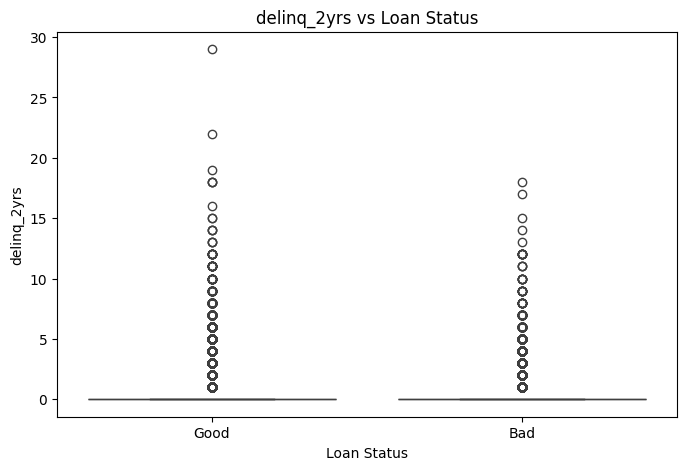


Mean per Class:
target
0    0.236204
1    0.273859
Name: delinq_2yrs, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


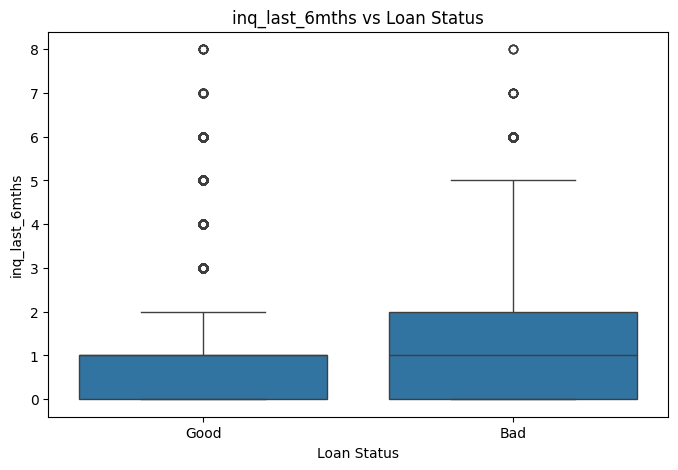


Mean per Class:
target
0    0.839346
1    0.993096
Name: inq_last_6mths, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


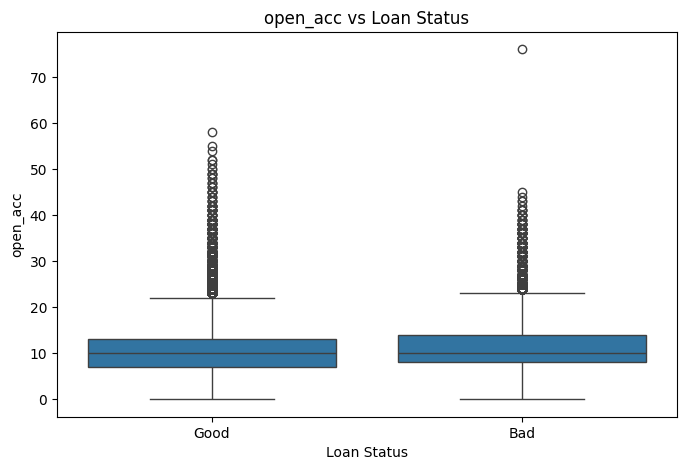


Mean per Class:
target
0    10.794407
1    11.017988
Name: open_acc, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


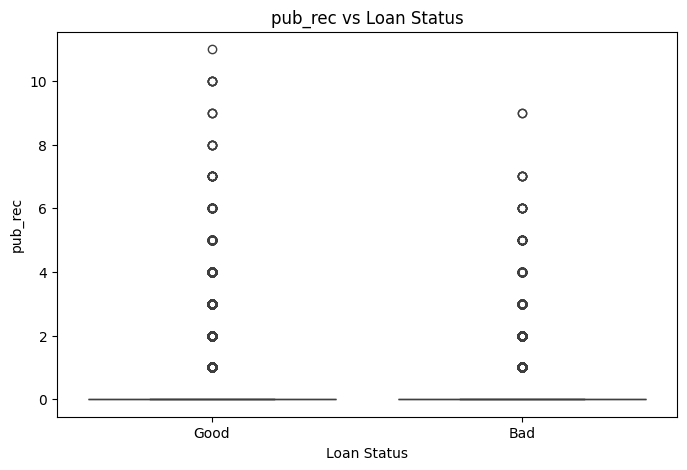


Mean per Class:
target
0    0.131494
1    0.140393
Name: pub_rec, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


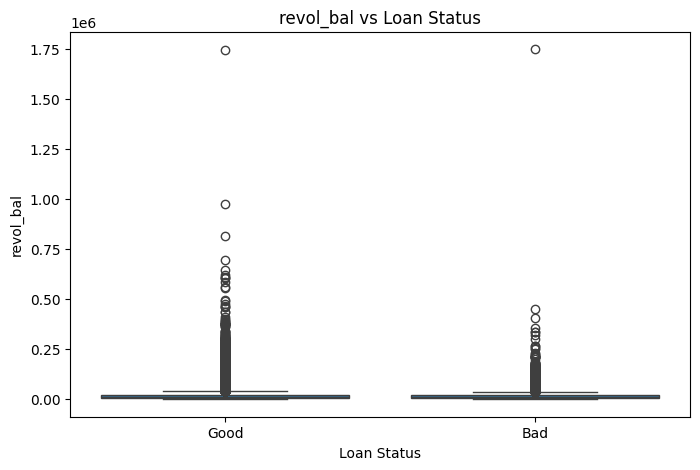


Mean per Class:
target
0    15112.548639
1    14914.234466
Name: revol_bal, dtype: float64


C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\237192016.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])


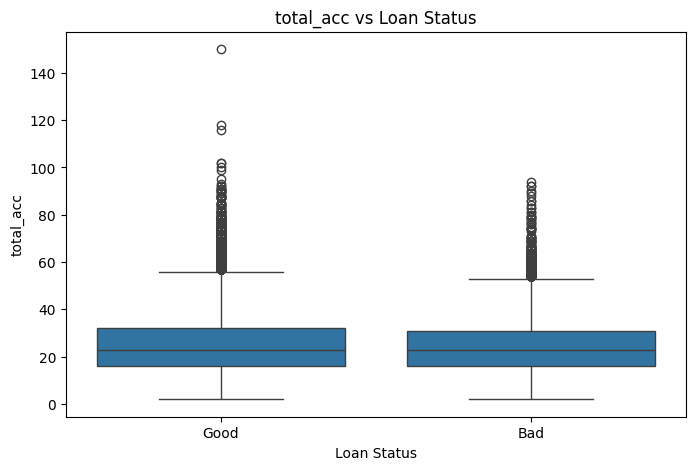


Mean per Class:
target
0    24.968686
1    24.164823
Name: total_acc, dtype: float64


In [ ]:
# Loop untuk Iterasi Semua Variabel Numerikal
for col in numerical_cols:
    bivariate_numeric_target(df_final, col, 'target')


##### **CATEGORICAL VS TARGET**

In [ ]:
# Fungsi untuk Analisis Bivariate Variabel Kategorikal vs Target
def bivariate_categorical_target(df, feature, target='target'):

    plt.figure(figsize=(12,5))
    
    # Mengatur hue_order dan palette supaya 0=Good, 1=Bad
    sns.countplot(
        data=df,
        x=feature,
        hue=target,
        hue_order=[0,1],
        palette={0:'green', 1:'red'}
    )
    
    plt.title(f'{feature} vs {target}')
    plt.xticks(rotation=45)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Loan Status', labels=['Good', 'Bad'])
    plt.show()
    
    # Proporsi target per kategori
    import pandas as pd
    prop = pd.crosstab(df[feature], df[target], normalize='index') * 100
    print(f"\nProportion of {target} per {feature} (%):")
    print(prop.round(2))

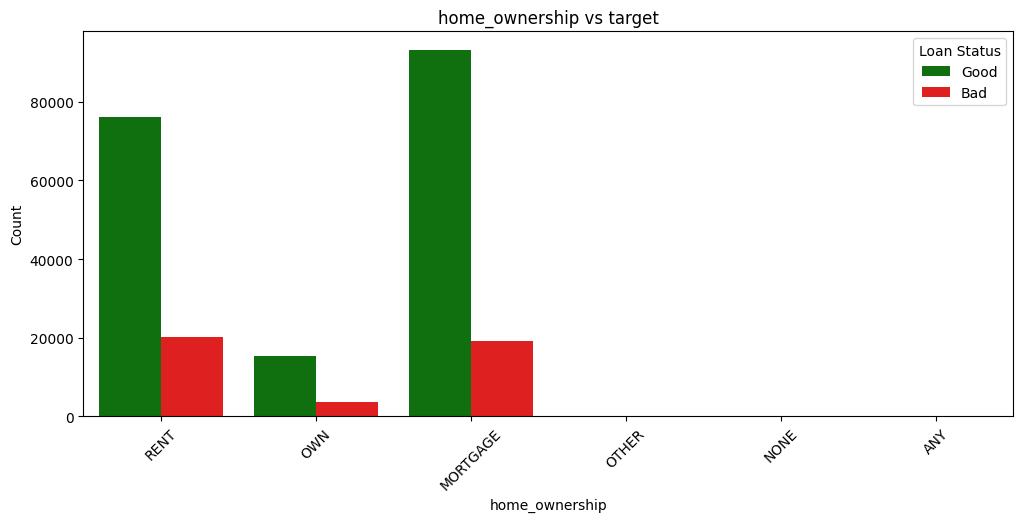


Proportion of target per home_ownership (%):
target               0      1
home_ownership               
ANY             100.00   0.00
MORTGAGE         82.96  17.04
NONE             83.72  16.28
OTHER            80.85  19.15
OWN              80.13  19.87
RENT             78.91  21.09


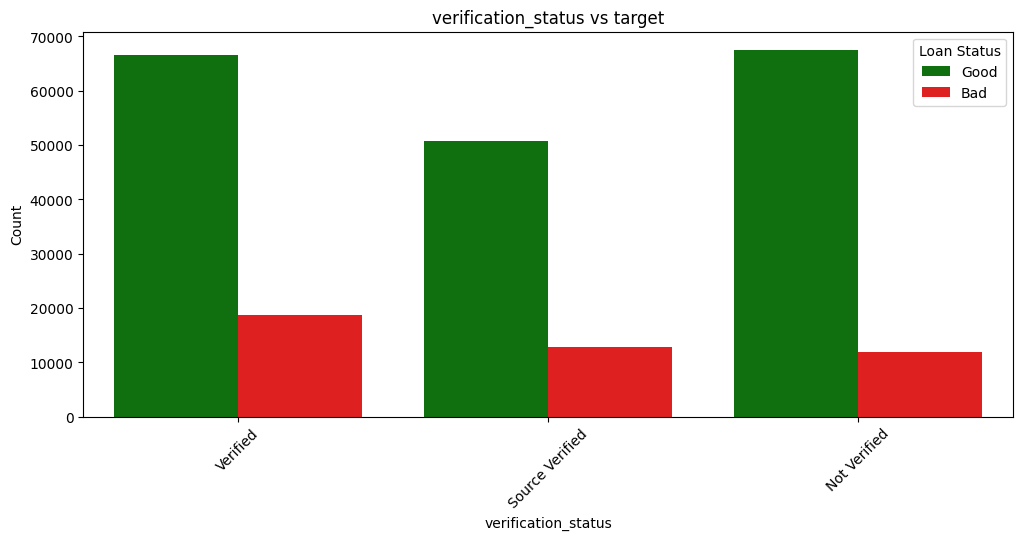


Proportion of target per verification_status (%):
target                  0     1
verification_status            
Not Verified         85.1  14.9
Source Verified      79.8  20.2
Verified             78.1  21.9


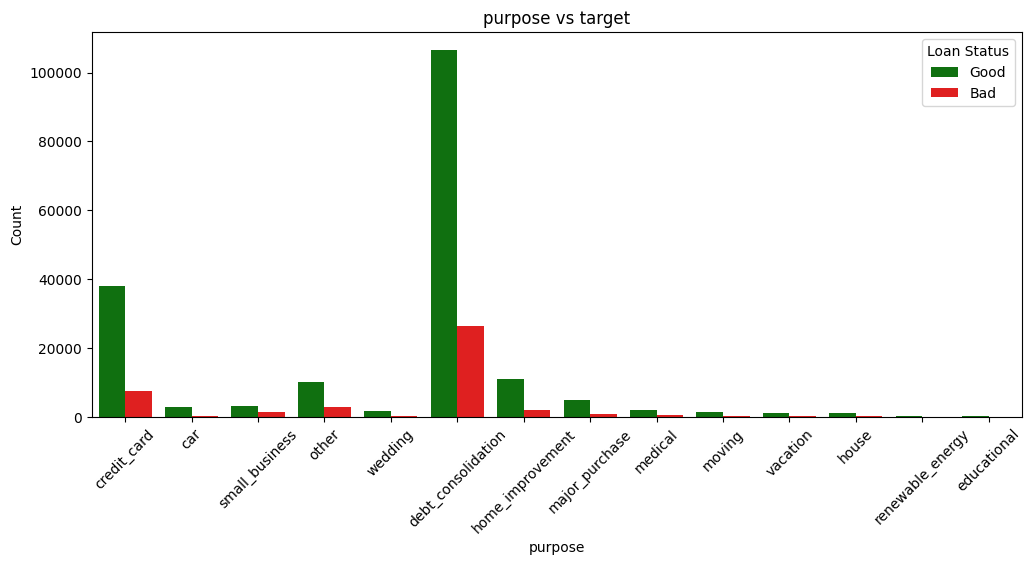


Proportion of target per purpose (%):
target                  0      1
purpose                         
car                 87.34  12.66
credit_card         83.50  16.50
debt_consolidation  80.14  19.86
educational         82.77  17.23
home_improvement    83.71  16.29
house               81.24  18.76
major_purchase      85.74  14.26
medical             79.46  20.54
moving              77.87  22.13
other               78.13  21.87
renewable_energy    79.68  20.32
small_business      70.33  29.67
vacation            81.68  18.32
wedding             86.44  13.56


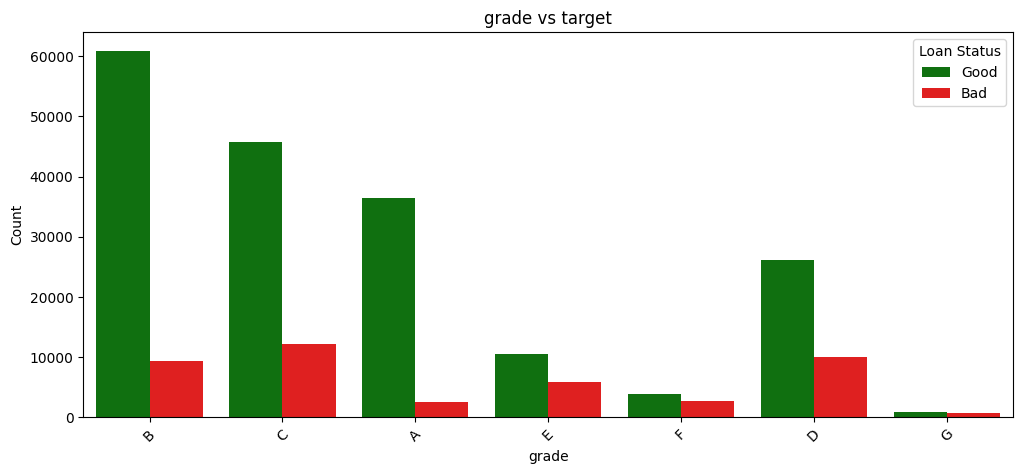


Proportion of target per grade (%):
target      0      1
grade               
A       93.45   6.55
B       86.76  13.24
C       79.00  21.00
D       72.37  27.63
E       64.41  35.59
F       59.06  40.94
G       55.29  44.71


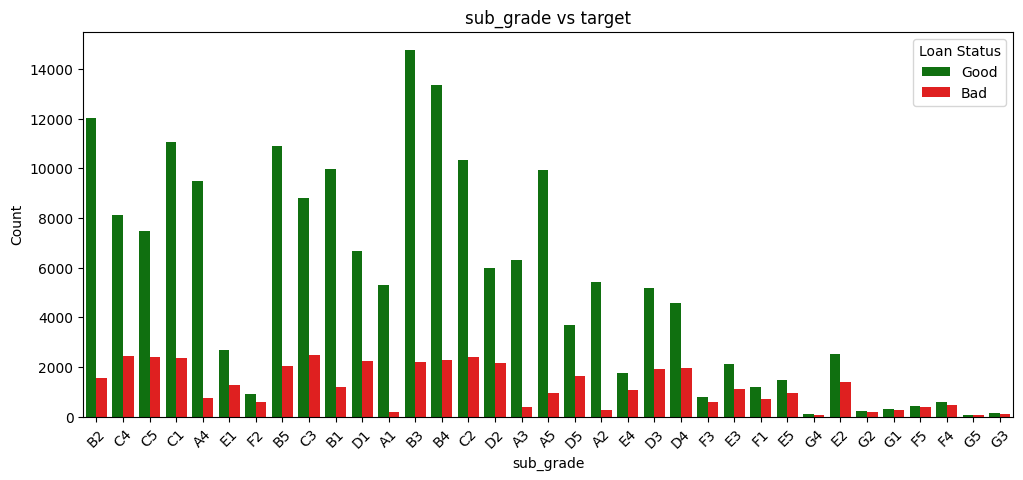


Proportion of target per sub_grade (%):
target         0      1
sub_grade              
A1         96.71   3.29
A2         95.23   4.77
A3         94.12   5.88
A4         92.59   7.41
A5         91.26   8.74
B1         89.36  10.64
B2         88.48  11.52
B3         86.92  13.08
B4         85.42  14.58
B5         84.09  15.91
C1         82.25  17.75
C2         80.99  19.01
C3         78.03  21.97
C4         76.72  23.28
C5         75.57  24.43
D1         74.64  25.36
D2         73.36  26.64
D3         72.91  27.09
D4         69.87  30.13
D5         69.40  30.60
E1         67.41  32.59
E2         64.48  35.52
E3         65.27  34.73
E4         62.37  37.63
E5         60.64  39.36
F1         62.41  37.59
F2         61.23  38.77
F3         57.48  42.52
F4         56.14  43.86
F5         53.66  46.34
G1         52.96  47.04
G2         56.94  43.06
G3         52.55  47.45
G4         64.18  35.82
G5         53.22  46.78


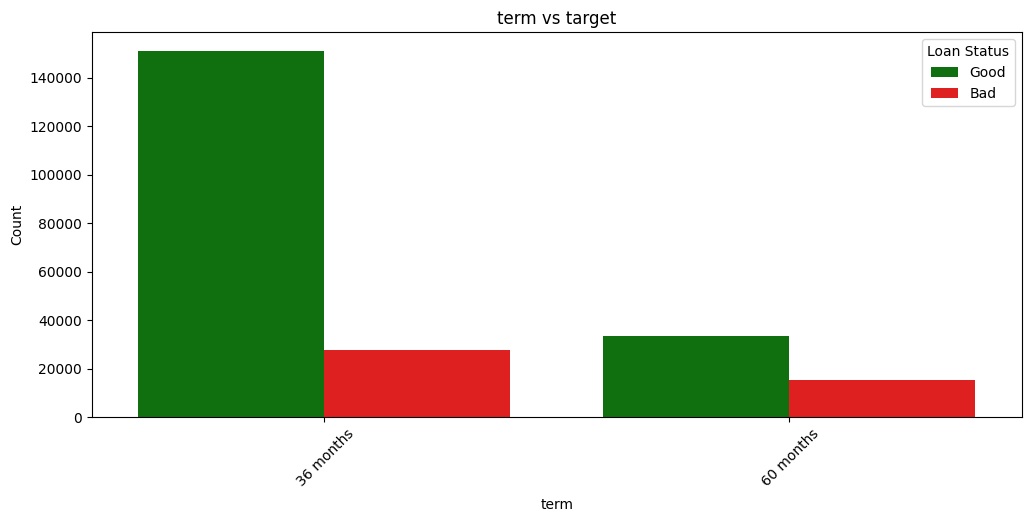


Proportion of target per term (%):
target         0      1
term                   
36 months  84.39  15.61
60 months  68.65  31.35


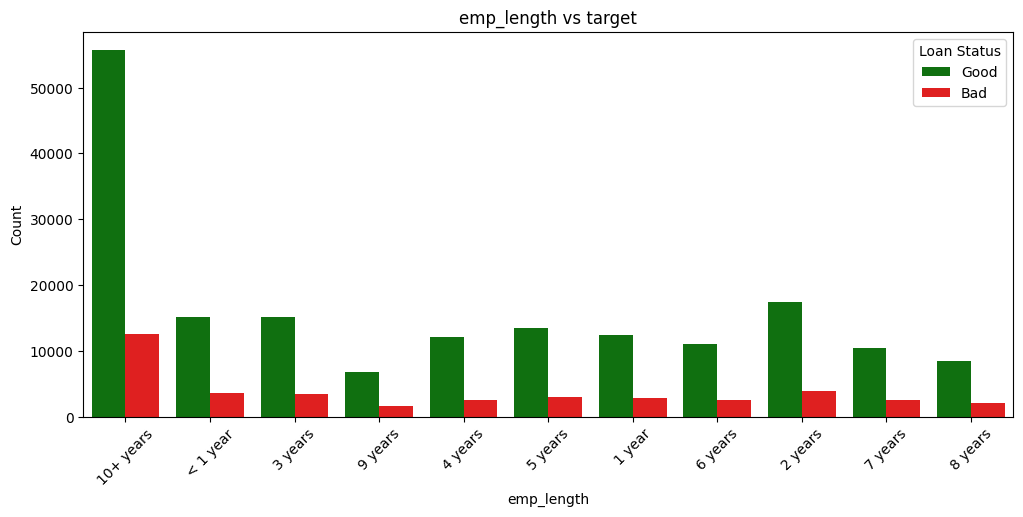


Proportion of target per emp_length (%):
target          0      1
emp_length              
1 year      81.66  18.34
10+ years   81.52  18.48
2 years     81.88  18.12
3 years     81.61  18.39
4 years     82.13  17.87
5 years     81.47  18.53
6 years     80.89  19.11
7 years     80.56  19.44
8 years     80.28  19.72
9 years     80.27  19.73
< 1 year    80.70  19.30


In [ ]:
# Loop untuk Iterasi Semua Variabel Kategorikal
for col in categorical_cols:
    bivariate_categorical_target(df_final, col, 'target')

### **CORRELATION ANALYSIS**

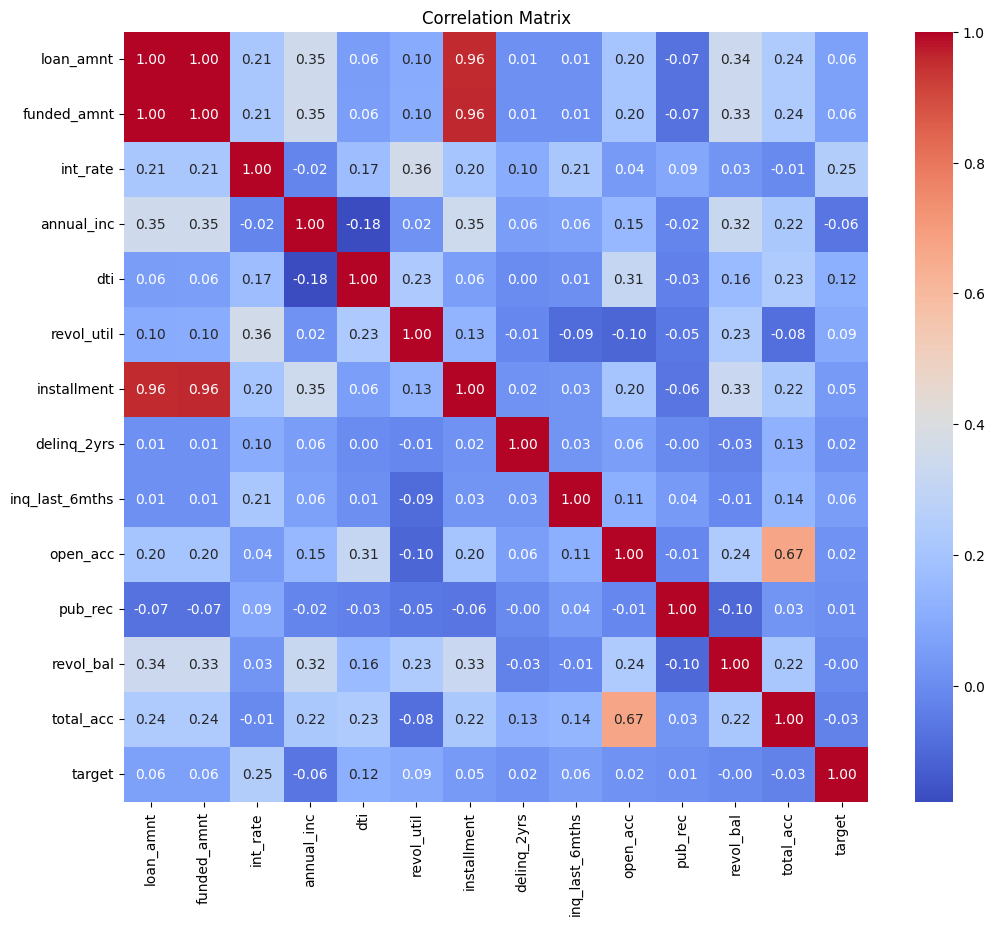

In [ ]:
# Correlationn Matrix untuk Variabel Numerikal + Target
plt.figure(figsize=(12,10))
sns.heatmap(df_final[numerical_cols + ['target']].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

----------

------------

---------------

# **DATA PREPARATION**

##### **SELEKSI FITUR & DROP VARIABEL REDUNDANT**

In [ ]:
# Drop Variabel Redundan Berdasarkan Correlation Matrix
numerical_cols.remove('funded_amnt') # Drop Variabel funded_amnt
categorical_cols.remove('grade') # Drop Variabel grade
numerical_cols.remove('open_acc') # Drop Variabel open_acc
numerical_cols.remove('installment') # Drop Variabel Installment

In [ ]:
# Menggabungkan Variabel Numerikal dan Kategorikal
feature_cols = numerical_cols + categorical_cols

df_model = df_final[feature_cols + ['target']].copy()

In [ ]:
# Mengecek Info Semua Variabel Setelah di Seleksi
df_model.info()

<class 'pandas.DataFrame'>
Index: 228046 entries, 0 to 466283
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            228046 non-null  int64  
 1   int_rate             228046 non-null  float64
 2   annual_inc           228046 non-null  float64
 3   dti                  228046 non-null  float64
 4   revol_util           227860 non-null  float64
 5   delinq_2yrs          228046 non-null  float64
 6   inq_last_6mths       228046 non-null  float64
 7   pub_rec              228046 non-null  float64
 8   revol_bal            228046 non-null  int64  
 9   total_acc            228046 non-null  float64
 10  home_ownership       228046 non-null  str    
 11  verification_status  228046 non-null  str    
 12  purpose              228046 non-null  str    
 13  sub_grade            228046 non-null  str    
 14  term                 228046 non-null  str    
 15  emp_length           219325 non-n

##### **DATA CLEANING**

In [ ]:
# Mengecek Tipe Data
df_model.dtypes

loan_amnt                int64
int_rate               float64
annual_inc             float64
dti                    float64
revol_util             float64
delinq_2yrs            float64
inq_last_6mths         float64
pub_rec                float64
revol_bal                int64
total_acc              float64
home_ownership             str
verification_status        str
purpose                    str
sub_grade                  str
term                       str
emp_length                 str
target                   int64
dtype: object

In [ ]:
# Menghapus Unsur String dalam Variabel emp_length & Mengubah Tipe Datanya dari String Menjadi Numerik
df_model['emp_length'] = df_model['emp_length'].str.replace(' years','', regex=False)
df_model['emp_length'] = df_model['emp_length'].str.replace(' year','', regex=False)
df_model['emp_length'] = df_model['emp_length'].str.replace('+','', regex=False)
df_model['emp_length'] = df_model['emp_length'].replace('< 1', '0')
df_model['emp_length'] = df_model['emp_length'].replace('nan', None)

df_model['emp_length'] = pd.to_numeric(df_model['emp_length'], errors='coerce')
df_model['emp_length'].unique()

In [ ]:
# Menghapus Unsutr String dalam Variabel term & Mengubah Tipe Datanya dari String Menjadi Numerik
df_model['term'] = (
    df_model['term']
    .astype(str)
    .str.extract('(\d+)')
)

df_model['term'] = pd.to_numeric(df_model['term'], errors='coerce')
df_model['term'].unique()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\3753829383.py:4: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')


array([36, 60])

In [ ]:
# Mengecek Tipe Data Setelah Melakukan Cleaning
df_model.dtypes

loan_amnt                int64
int_rate               float64
annual_inc             float64
dti                    float64
revol_util             float64
delinq_2yrs            float64
inq_last_6mths         float64
pub_rec                float64
revol_bal                int64
total_acc              float64
home_ownership             str
verification_status        str
purpose                    str
sub_grade                  str
term                     int64
emp_length             float64
target                   int64
dtype: object

##### **SPLIT DATA**

In [ ]:
# Split Data dengan Ukuran 80:20
X = df_model.drop('target', axis=1)
y = df_model['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [106]:
# Memisahkan Numerical dan Categorical 
numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

C:\Users\Syarief Hidayat\AppData\Local\Temp\ipykernel_21012\367095119.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns


##### **IMPUTASI**

In [ ]:
# Imputasi untuk Variabel Numerikal dengan Mengganti Missing Value Menjadi Median dari Variabel Tersebut
for col in numerical_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [ ]:
# Imputasi untuk Variabel Kategorikal dengan Mengganti Missing Value Menjadi Unknown 
for col in categorical_cols:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

In [ ]:
# Memastikan Tidak Ada Missing Value Lagi

X_train.isna().sum().sum()
X_test.isna().sum().sum()

np.int64(0)

##### **OUTLIER HANDLING**

In [112]:
# CAPPING (WINSORIZING)
for col in numerical_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

##### **ENCODING**

In [ ]:
# Merubah Variabel Kategorikal menjadi Biner dengan Metode One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Samakan kolom train & test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

##### **FEATURE ENGINEERING**

In [ ]:
# Membuat Fitur Baru berdasarkan Fitur yang Telah Ada (Feature Engineering)
for df in [X_train, X_test]:
    df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] # Loan to Income Ratio
    df['log_annual_inc'] = np.log1p(df['annual_inc']) # Log Transformation for Annual Income
    df['dti_x_revol'] = df['dti'] * df['revol_util'] # Interaction dti and revol_util
    df['emp_stability_ratio'] = df['emp_length'] / df['term'] # Employment stability
    df['credit_behavior_score'] = df['delinq_2yrs'] + df['inq_last_6mths'] + df['pub_rec'] # Behavior Aggregation

##### **SCALING**

In [ ]:
# Standarisasi Data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

------------------------

-----------------------

----------------------

# **DATA MODELING**

### **LOGICTIC REGRESSION**

In [117]:
# Training
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [118]:
# Prediction
y_pred_log = logreg.predict(X_test_scaled)
y_proba_log = logreg.predict_proba(X_test_scaled)[:,1]

In [119]:
# Evaluation Metrics for LR
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_log))

ROC-AUC: 0.7050865692114376

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.64      0.74     36948
           1       0.30      0.66      0.41      8662

    accuracy                           0.64     45610
   macro avg       0.59      0.65      0.58     45610
weighted avg       0.78      0.64      0.68     45610



In [ ]:
# Overfitting Check
train_auc_log = roc_auc_score(
    y_train,
    logreg.predict_proba(X_train_scaled)[:,1]
)

test_auc_log = roc_auc_score(
    y_test,
    logreg.predict_proba(X_test_scaled)[:,1]
)

print("Train AUC Logistic:", train_auc_log)
print("Test AUC Logistic:", test_auc_log)

Train AUC Logistic: 0.7084413176182393
Test AUC Logistic: 0.7050865692114376


<Figure size 400x400 with 0 Axes>

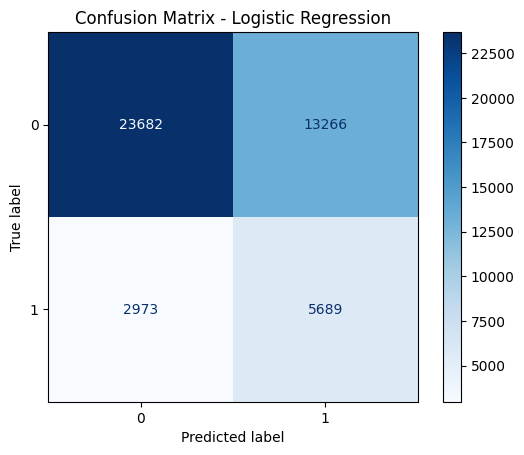

In [ ]:
# Confusion Matrix
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

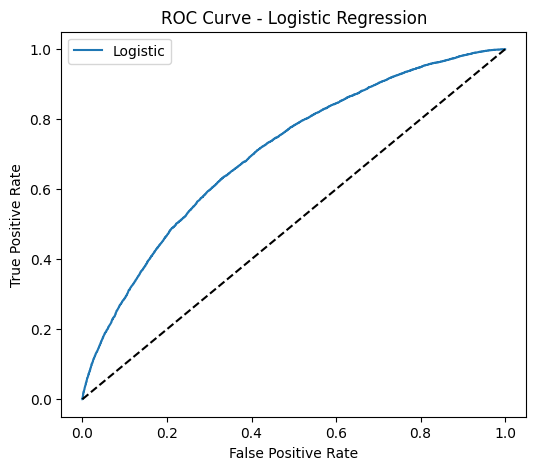

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### **RANDOM FOREST**

In [124]:
# Training
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [125]:
# Prediction
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
# Evaluation Metrics for RF
print("ROC-AUC RF:", roc_auc_score(y_test, y_proba_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

ROC-AUC RF: 0.7017089135386989

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.66      0.76     36948
           1       0.31      0.63      0.41      8662

    accuracy                           0.66     45610
   macro avg       0.60      0.65      0.58     45610
weighted avg       0.78      0.66      0.69     45610



In [128]:
# Overfitting Check
train_auc_rf = roc_auc_score(y_train, rf.predict_proba(X_train)[:,1])
test_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Train AUC:", train_auc_rf)
print("Test AUC:", test_auc_rf)

Train AUC: 0.7349525256017871
Test AUC: 0.7017089135386989


<Figure size 400x400 with 0 Axes>

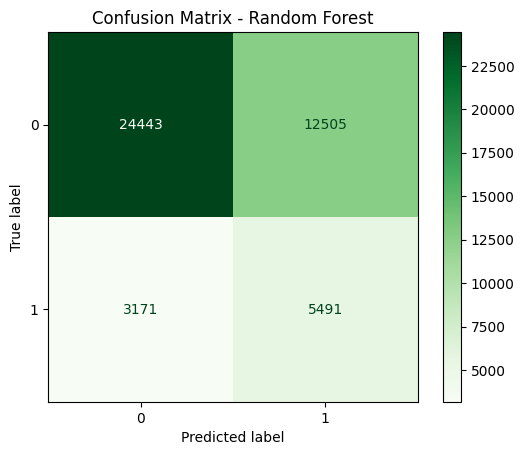

In [ ]:
# Confusion Matrix
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens"
)
plt.title("Confusion Matrix - Random Forest")
plt.show()

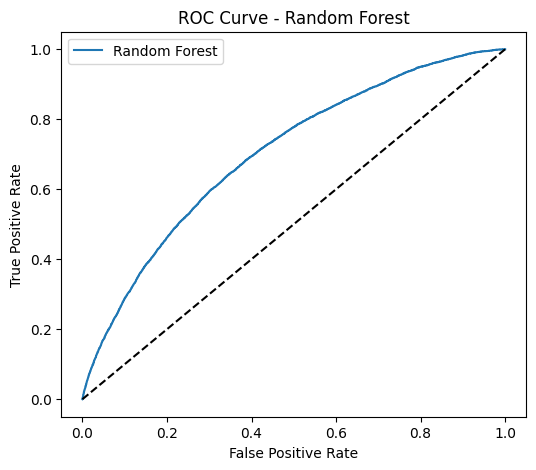

In [ ]:
# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')  # garis random

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### **XGBOOST**

In [ ]:
# Training
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [132]:
# Prediction
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

In [ ]:
# Evalution Metrics for XGBoost
print("ROC-AUC XGB:", roc_auc_score(y_test, y_proba_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

ROC-AUC XGB: 0.7085510427492536

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.65      0.75     36948
           1       0.31      0.65      0.42      8662

    accuracy                           0.65     45610
   macro avg       0.60      0.65      0.58     45610
weighted avg       0.78      0.65      0.69     45610



In [ ]:
# Overfitting Check
train_auc_xgb = roc_auc_score(
    y_train, xgb.predict_proba(X_train)[:,1]
)

test_auc_xgb = roc_auc_score(
    y_test, y_proba_xgb
)

print("Train AUC XGB:", train_auc_xgb)
print("Test AUC XGB:", test_auc_xgb)

Train AUC XGB: 0.7351301946556607
Test AUC XGB: 0.7085510427492536


<Figure size 400x400 with 0 Axes>

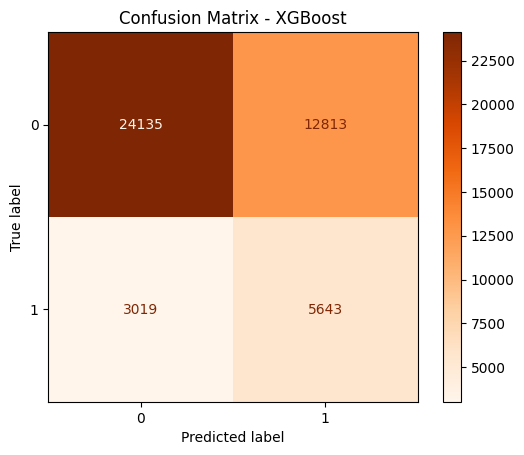

In [ ]:
# Confusion Matrix
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Oranges"
)
plt.title("Confusion Matrix - XGBoost")
plt.show()

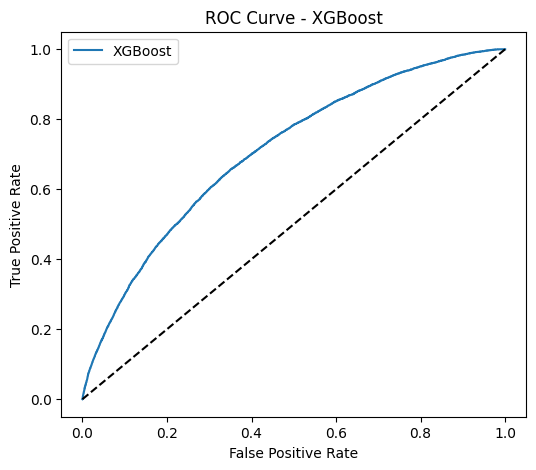

In [ ]:
# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

----------------------

-------------------------

-----------------------

# **MODEL EVALUATION**

### **PERBANDINGAN AUC, RECALL, PRECISION, F1-SCORE**

In [ ]:
# Logistic
report_log = classification_report(y_test, y_pred_log, output_dict=True)

# RF
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# XGB
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

In [ ]:
# Tabel Perbandingan Metrik Evaluasi Ketiga Algoritma
comparison_df = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "XGBoost"],
    
    "Train AUC": [
        train_auc_log,
        train_auc_rf,
        train_auc_xgb
    ],
    
    "Test AUC": [
        test_auc_log,
        test_auc_rf,
        test_auc_xgb
    ],
    
    "AUC Gap": [
        train_auc_log - test_auc_log,
        train_auc_rf - test_auc_rf,
        train_auc_xgb - test_auc_xgb
    ],
    
    "Recall (Bad)": [
        report_log["1"]["recall"],
        report_rf["1"]["recall"],
        report_xgb["1"]["recall"]
    ],
    
    "Precision (Bad)": [
        report_log["1"]["precision"],
        report_rf["1"]["precision"],
        report_xgb["1"]["precision"]
    ],

    "F1-Score (Bad)": [
        report_log["1"]["f1-score"],
        report_rf["1"]["f1-score"],
        report_xgb["1"]["f1-score"]
    ]
    
})

comparison_df

,Model,Train AUC,Test AUC,AUC Gap,Recall (Bad),Precision (Bad),F1-Score (Bad)
0,Logistic,0.708441,0.705087,0.003355,0.656777,0.300132,0.411993
1,Random Forest,0.734953,0.701709,0.033244,0.633918,0.305123,0.411959
2,XGBoost,0.735130,0.708551,0.026579,0.651466,0.305754,0.416181


### **PERBANDINGAN CONFUSION MATRIX**

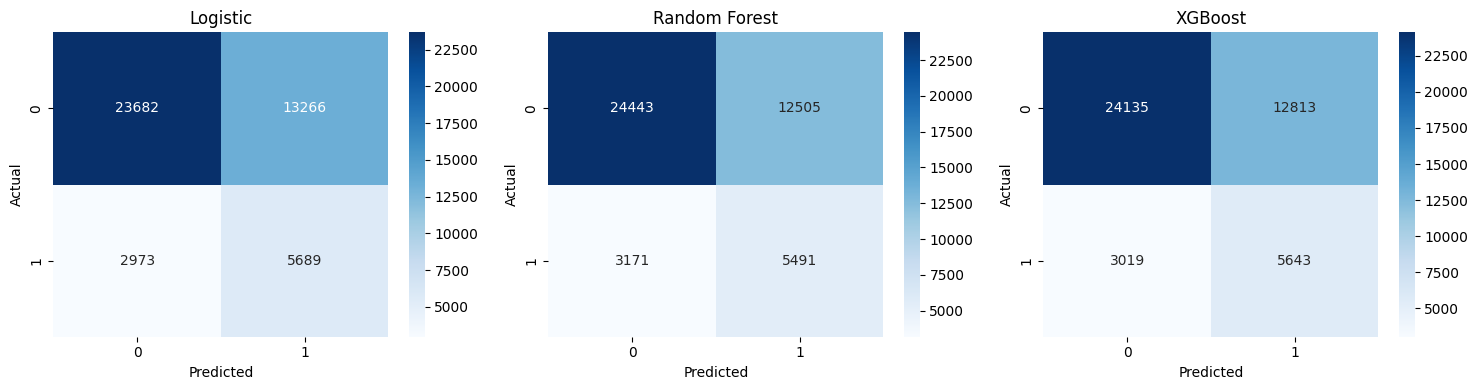

In [ ]:
# Perbandingan Confusion Matrix Ketiga Algoritma
fig, axes = plt.subplots(1, 3, figsize=(15,4))

models = [
    ("Logistic", y_pred_log),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### **PERBANDINGAN ROC CURVE**

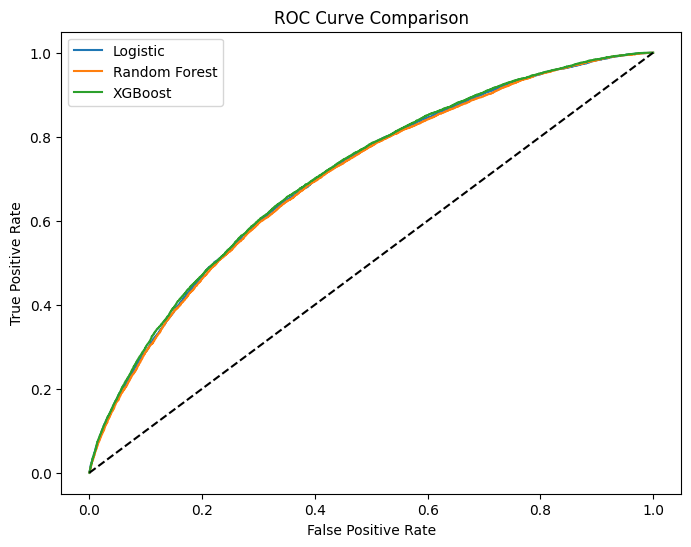

In [ ]:
# Perbandingan ROC Curve Ketiga Algoritma
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Berdasarkan modeling ditentukan bahwa XGBoost dipilih sebagai model terbaik